In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from datasets import load_dataset
import ast
import seaborn as sns
import matplotlib.pyplot as plt

dataset=load_dataset('lukebarousse/data_jobs')
df=dataset['train'].to_pandas()

df['job_posted_date']=pd.to_datetime(df['job_posted_date'])
df['job_skills']=df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

c:\Users\Harsh Kaushik\anaconda3\envs\python_course\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
df_DA_india=df[(df['job_title']=='Data Analyst') & (df['job_country']=='India')].copy()
df_DA_india=df_DA_india.dropna(subset=['salary_year_avg'])
df_DA_india_exploded=df_DA_india.explode('job_skills')
df_DA_india_exploded[['salary_year_avg','job_skills']].head(5)

,salary_year_avg,job_skills
56450,57500.0,tableau
56450,57500.0,power bi
60528,105000.0,r
60528,105000.0,python
60528,105000.0,spss


In [10]:
df_DA_skills=df_DA_india_exploded.groupby('job_skills')['salary_year_avg'].agg(['count','median']).sort_values(by='count',ascending=False)
df_DA_skills=df_DA_skills.rename(columns={'count':'skill_count','median':'median_salary'})
DA_job_count=len(df_DA_india)
df_DA_skills['skill_percentage']=df_DA_skills['skill_count']/DA_job_count*100
skill_percent=5
df_DA_skills_high_demand=df_DA_skills[df_DA_skills['skill_percentage']>skill_percent]

14 [ 0.3529777  -0.55409459]
19 [ 0.80800125 -0.99344526]


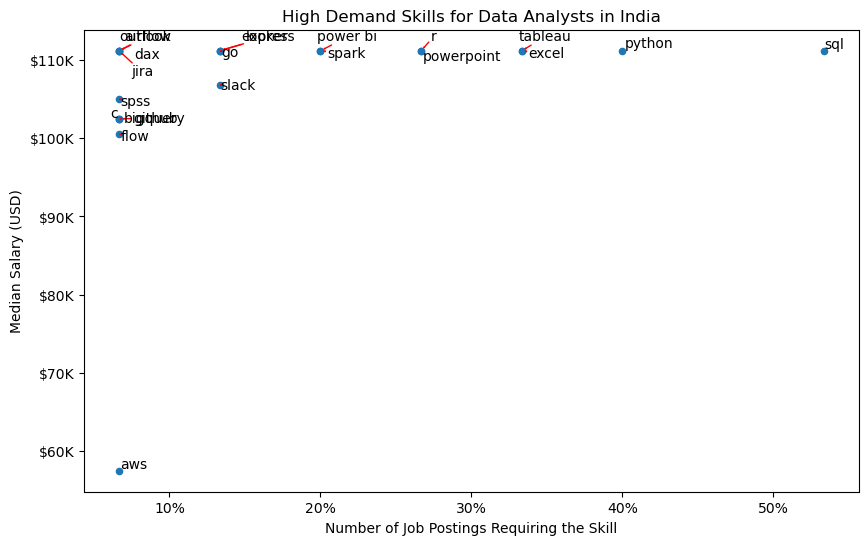

<Figure size 640x480 with 0 Axes>

In [18]:
from adjustText import adjust_text
from matplotlib.ticker import PercentFormatter
df_DA_skills_high_demand.plot(kind='scatter', x='skill_percentage', y='median_salary', figsize=(10,6))
texts=[]
for i,txt in enumerate(df_DA_skills_high_demand.index):
    texts.append(plt.text(df_DA_skills_high_demand['skill_percentage'].iloc[i], df_DA_skills_high_demand['median_salary'].iloc[i], txt))

adjust_text(texts, arrowprops=dict(arrowstyle='->', color='red'))
plt.title('High Demand Skills for Data Analysts in India')
plt.xlabel('Number of Job Postings Requiring the Skill')
plt.ylabel('Median Salary (USD)')
ax=plt.gca()
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, pos: f'${int(x/1000)}K'))
ax.xaxis.set_major_formatter(PercentFormatter())
plt.show()
plt.tight_layout()
plt.show()